In [1]:
!pip install pandas scikit-learn matplotlib seaborn joblib imbalanced-learn

In [ ]:
# OPTION A — Download CICIDS2017 from Kaggle (recommended)
# Step 1: Go to https://www.kaggle.com/datasets/cicdataset/cicids2017
# Step 2: Download "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
# Step 3: Place it in notebooks/data/ folder

# OPTION B — Download UNSW-NB15 from Kaggle
# Link: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
# Download: UNSW_NB15_training-set.csv

# OPTION C — Use your own generated logs (no download needed)
# Run this if you don't want to download datasets:

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

print("All libraries loaded")

All libraries loaded


In [4]:
DATASET_PATH = "data/cicids2017_cleaned.csv"

df_raw = pd.read_csv(DATASET_PATH)

print(f"Rows    : {len(df_raw):,}")
print(f"Columns : {df_raw.shape[1]}")
print(f"\nAll column names:")
for i, col in enumerate(df_raw.columns.tolist()):
    print(f"  {i:>2}. '{col}'")

Rows    : 2,520,751
Columns : 53

All column names:
   0. 'Destination Port'
   1. 'Flow Duration'
   2. 'Total Fwd Packets'
   3. 'Total Length of Fwd Packets'
   4. 'Fwd Packet Length Max'
   5. 'Fwd Packet Length Min'
   6. 'Fwd Packet Length Mean'
   7. 'Fwd Packet Length Std'
   8. 'Bwd Packet Length Max'
   9. 'Bwd Packet Length Min'
  10. 'Bwd Packet Length Mean'
  11. 'Bwd Packet Length Std'
  12. 'Flow Bytes/s'
  13. 'Flow Packets/s'
  14. 'Flow IAT Mean'
  15. 'Flow IAT Std'
  16. 'Flow IAT Max'
  17. 'Flow IAT Min'
  18. 'Fwd IAT Total'
  19. 'Fwd IAT Mean'
  20. 'Fwd IAT Std'
  21. 'Fwd IAT Max'
  22. 'Fwd IAT Min'
  23. 'Bwd IAT Total'
  24. 'Bwd IAT Mean'
  25. 'Bwd IAT Std'
  26. 'Bwd IAT Max'
  27. 'Bwd IAT Min'
  28. 'Fwd Header Length'
  29. 'Bwd Header Length'
  30. 'Fwd Packets/s'
  31. 'Bwd Packets/s'
  32. 'Min Packet Length'
  33. 'Max Packet Length'
  34. 'Packet Length Mean'
  35. 'Packet Length Std'
  36. 'Packet Length Variance'
  37. 'FIN Flag Count'
  38. '

In [5]:
print("=== Column Names ===")
print(df_raw.columns.tolist())

print("\n=== Data Types ===")
print(df_raw.dtypes.value_counts())

print("\n=== Missing Values ===")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.any() else "No missing values ")

print("\n=== Sample Rows ===")
df_raw.head(3)

=== Column Names ===
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Active Min', 'Idle M

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.97561,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.97561,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.00000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [7]:
# Label column is "Attack Type", normal = "Normal Traffic"
df_raw["label_binary"] = df_raw["Attack Type"].apply(
    lambda x: 0 if str(x).strip() == "Normal Traffic" else 1
)

benign  = (df_raw["label_binary"] == 0).sum()
attacks = (df_raw["label_binary"] == 1).sum()
total   = len(df_raw)

print("=" * 40)
print(f"  NORMAL  : {benign:>8,}  ({benign/total*100:.1f}%)")
print(f"  ATTACKS : {attacks:>8,}  ({attacks/total*100:.1f}%)")
print(f"  TOTAL   : {total:>8,}")
print("=" * 40)

# Show attack type breakdown
print("\nAttack types in dataset:")
print(df_raw["Attack Type"].value_counts())

  NORMAL  : 2,095,057  (83.1%)
  ATTACKS :  425,694  (16.9%)
  TOTAL   : 2,520,751

Attack types in dataset:
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


In [9]:
# These columns confirmed present in your dataset
CICIDS_TO_SENTINEL = {
    "Flow Packets/s"               : "requests_per_ip",
    "Flow Bytes/s"                 : "payload_size",
    "Flow Duration"                : "response_time",
    "Fwd Packet Length Max"        : "suspicious_endpoint",
    "Bwd Packet Length Max"        : "suspicious_agent",
    "Average Packet Size"          : "error_rate",
}

df = pd.DataFrame()
for orig_col, new_col in CICIDS_TO_SENTINEL.items():
    df[new_col] = df_raw[orig_col]

df["label"] = df_raw["label_binary"]

print(f"Feature dataframe shape: {df.shape}")
print(df.head(3))

Feature dataframe shape: (2520751, 7)
   requests_per_ip  payload_size  response_time  suspicious_endpoint  \
0        67.122468    7595.10464        1266342                  456   
1        64.425518    7289.93681        1319353                  456   
2     12500.000000       0.00000            160                    0   

   suspicious_agent  error_rate  label  
0               976  113.152941      0  
1               976  113.152941      0  
2                 0    0.000000      0  


In [10]:
FEATURE_COLS = [
    "requests_per_ip",
    "payload_size",
    "response_time",
    "error_rate",
    "suspicious_endpoint",
    "suspicious_agent",
]

df[FEATURE_COLS] = df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(0)

for col in FEATURE_COLS:
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper)

print("Features cleaned")
print(df[FEATURE_COLS].describe().round(2))

✅ Features cleaned
       requests_per_ip  payload_size  response_time  error_rate  \
count       2520751.00  2.520751e+06   2.520751e+06  2520751.00   
mean          38481.68  4.960908e+05   1.658154e+07      210.42   
std          135187.68  1.774633e+06   3.520599e+07      337.24   
min        -2000000.00 -2.610000e+08  -1.300000e+01        0.00   
25%               2.02  1.194300e+02   2.080000e+02        9.00   
50%              69.75  3.715050e+03   5.062000e+04       81.00   
75%           17857.14  1.071429e+05   5.332968e+06      179.91   
max          750000.00  1.233333e+07   1.179103e+08     1454.12   

       suspicious_endpoint  suspicious_agent  
count           2520751.00        2520751.00  
mean                200.34            968.24  
std                 467.16           2005.45  
min                   0.00              0.00  
25%                   6.00              6.00  
50%                  40.00             97.00  
75%                 202.00            746.00  
m

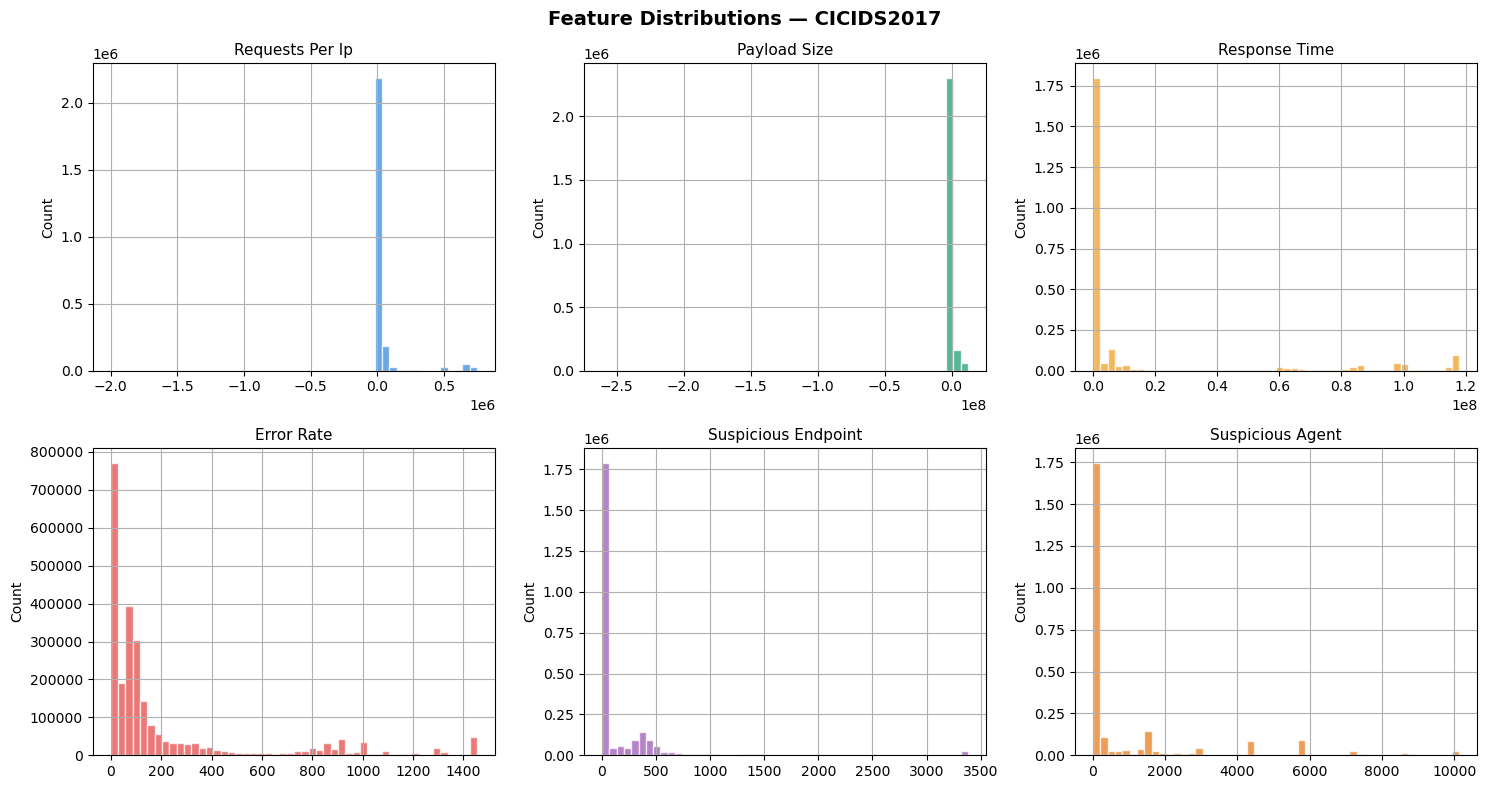

Saved → outputs/feature_distributions.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Feature Distributions — CICIDS2017", fontsize=14, fontweight="bold")

colors = ["#378ADD", "#1D9E75", "#EF9F27", "#E24B4A", "#9B59B6", "#E67E22"]

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i // 3][i % 3]
    df[col].hist(bins=50, ax=ax, color=colors[i], alpha=0.75, edgecolor="white")
    ax.set_title(col.replace("_", " ").title(), fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/feature_distributions.png")

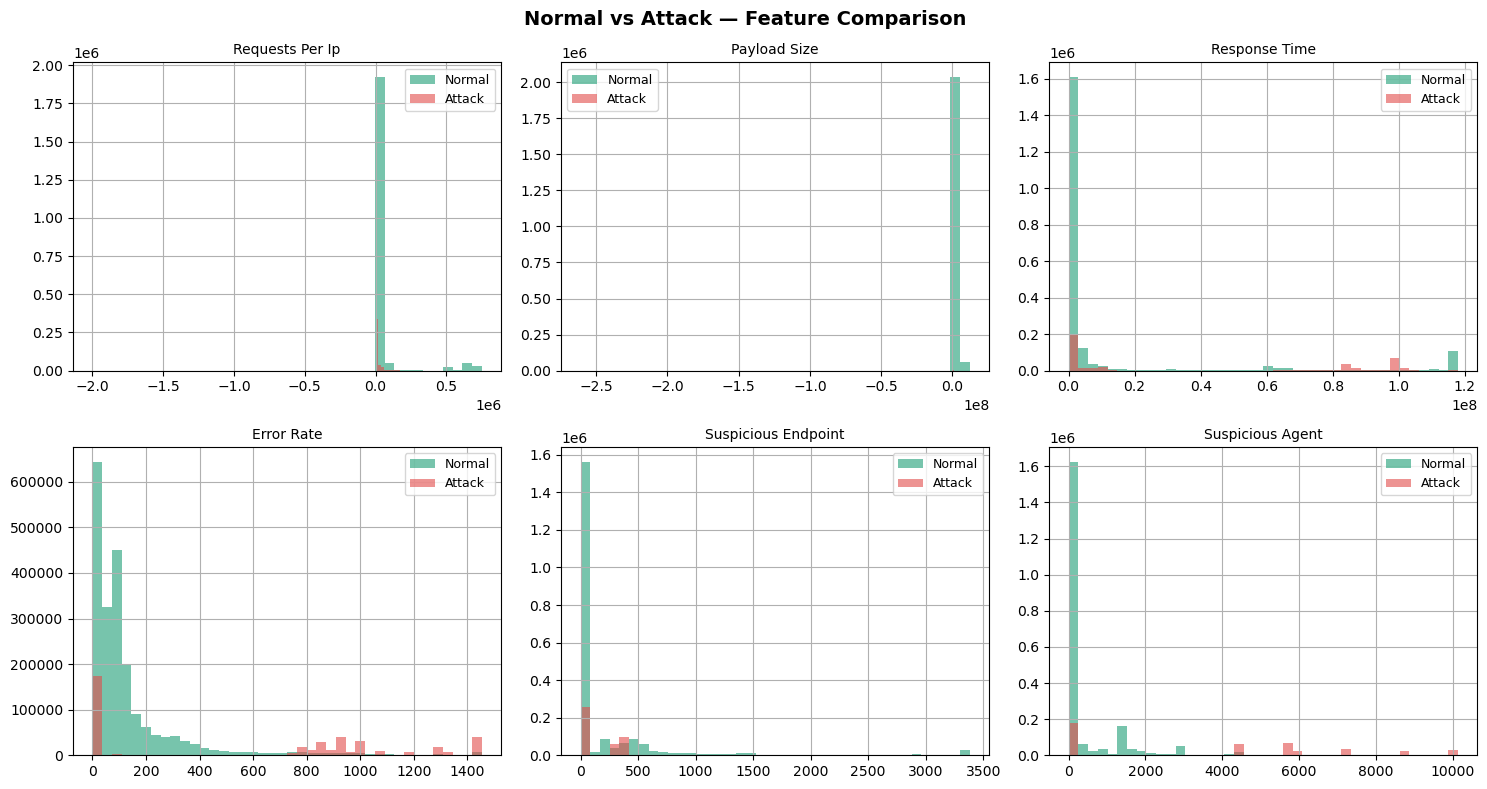

Saved → outputs/normal_vs_attack.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Normal vs Attack — Feature Comparison", fontsize=14, fontweight="bold")

normal_df = df[df["label"] == 0]
attack_df = df[df["label"] == 1]

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i // 3][i % 3]
    normal_df[col].hist(bins=40, ax=ax, alpha=0.6, color="#1D9E75", label="Normal")
    attack_df[col].hist(bins=40, ax=ax, alpha=0.6, color="#E24B4A", label="Attack")
    ax.set_title(col.replace("_", " ").title(), fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/normal_vs_attack.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/normal_vs_attack.png")

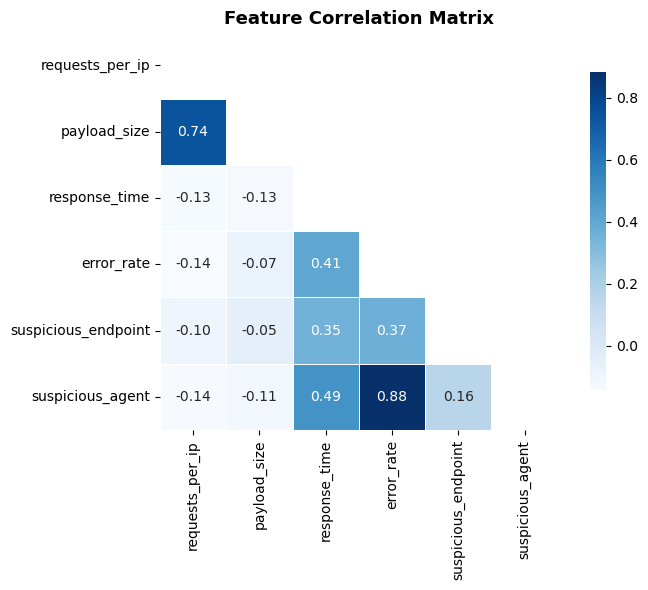

In [13]:
plt.figure(figsize=(8, 6))

corr = df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    mask=mask,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Dataset may have 2M+ rows — sample it for faster training
# Keep all attacks + sample equal normal traffic

SAMPLE_SIZE = 50000  # adjust based on your RAM

attack_df  = df[df["label"] == 1]
normal_df  = df[df["label"] == 0]

# Sample normal to match or cap at SAMPLE_SIZE
normal_sample = normal_df.sample(
    n=min(SAMPLE_SIZE, len(normal_df)),
    random_state=42
)
attack_sample = attack_df.sample(
    n=min(SAMPLE_SIZE, len(attack_df)),
    random_state=42
)

df_balanced = pd.concat([normal_sample, attack_sample]).sample(frac=1, random_state=42)

print(f"Balanced dataset size : {len(df_balanced):,}")
print(f"Normal  : {(df_balanced['label']==0).sum():,}")
print(f"Attacks : {(df_balanced['label']==1).sum():,}")

Balanced dataset size : 100,000
Normal  : 50,000
Attacks : 50,000


In [15]:
X = df_balanced[FEATURE_COLS].values
y = df_balanced["label"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

os.makedirs("../models", exist_ok=True)
joblib.dump(scaler, "../models/scaler.pkl")

print(f" Features scaled")
print(f"   Shape  : {X_scaled.shape}")
print(f"   Mean   : {X_scaled.mean(axis=0).round(3)}")
print(f"   Std    : {X_scaled.std(axis=0).round(3)}")
print(f"   Scaler saved → ../models/scaler.pkl")

✅ Features scaled
   Shape  : (100000, 6)
   Mean   : [ 0. -0. -0.  0. -0.  0.]
   Std    : [1. 1. 1. 1. 1. 1.]
   Scaler saved → ../models/scaler.pkl


In [16]:
print("Training Isolation Forest on CICIDS2017...")
print("This may take 1-2 minutes...\n")

model = IsolationForest(
    n_estimators=200,
    contamination=0.15,   # ~15% attacks in balanced set
    max_samples=0.8,
    max_features=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

model.fit(X_scaled)

# Predict
raw_scores = model.decision_function(X_scaled)
predictions = model.predict(X_scaled)

df_balanced = df_balanced.copy()
df_balanced["prediction"]   = predictions
df_balanced["anomaly_score_raw"] = raw_scores
df_balanced["anomaly_score"] = np.interp(
    raw_scores, (raw_scores.min(), raw_scores.max()), (100, 0)
)
df_balanced["is_anomaly"] = (predictions == -1).astype(int)

flagged = (predictions == -1).sum()
print(f"Training complete")
print(f"   Total samples   : {len(predictions):,}")
print(f"   Flagged         : {flagged:,} ({flagged/len(predictions)*100:.1f}%)")

Training Isolation Forest on CICIDS2017...
This may take 1-2 minutes...

Training complete
   Total samples   : 100,000
   Flagged         : 15,000 (15.0%)


  Model Evaluation — CICIDS2017
                 precision    recall  f1-score   support

Normal (BENIGN)      0.486     0.827     0.613     50000
         Attack      0.423     0.127     0.195     50000

       accuracy                          0.477    100000
      macro avg      0.455     0.477     0.404    100000
   weighted avg      0.455     0.477     0.404    100000



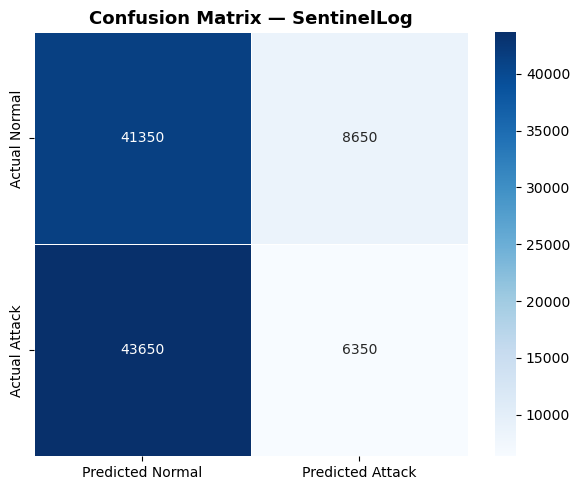


  ROC AUC Score : 0.5366


In [17]:
y_true = y
y_pred = df_balanced["is_anomaly"].values

print("=" * 50)
print("  Model Evaluation — CICIDS2017")
print("=" * 50)
print(classification_report(
    y_true, y_pred,
    target_names=["Normal (BENIGN)", "Attack"],
    digits=3
))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Attack"],
    yticklabels=["Actual Normal", "Actual Attack"],
    linewidths=0.5,
)
plt.title("Confusion Matrix — SentinelLog", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ROC AUC
try:
    auc = roc_auc_score(y_true, df_balanced["anomaly_score"].values)
    print(f"\n  ROC AUC Score : {auc:.4f}")
except:
    print("ROC AUC could not be computed")

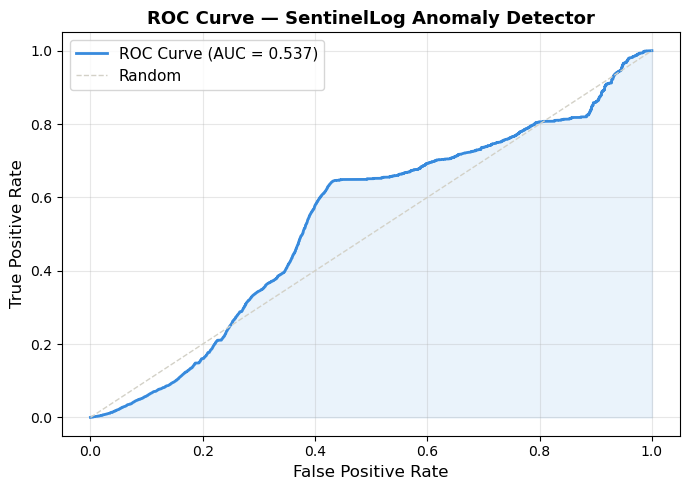

In [18]:
fpr, tpr, thresholds = roc_curve(y_true, df_balanced["anomaly_score"].values)
auc_score = roc_auc_score(y_true, df_balanced["anomaly_score"].values)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#378ADD", lw=2, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="#D3D1C7", lw=1, linestyle="--", label="Random")
plt.fill_between(fpr, tpr, alpha=0.1, color="#378ADD")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — SentinelLog Anomaly Detector", fontsize=13, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

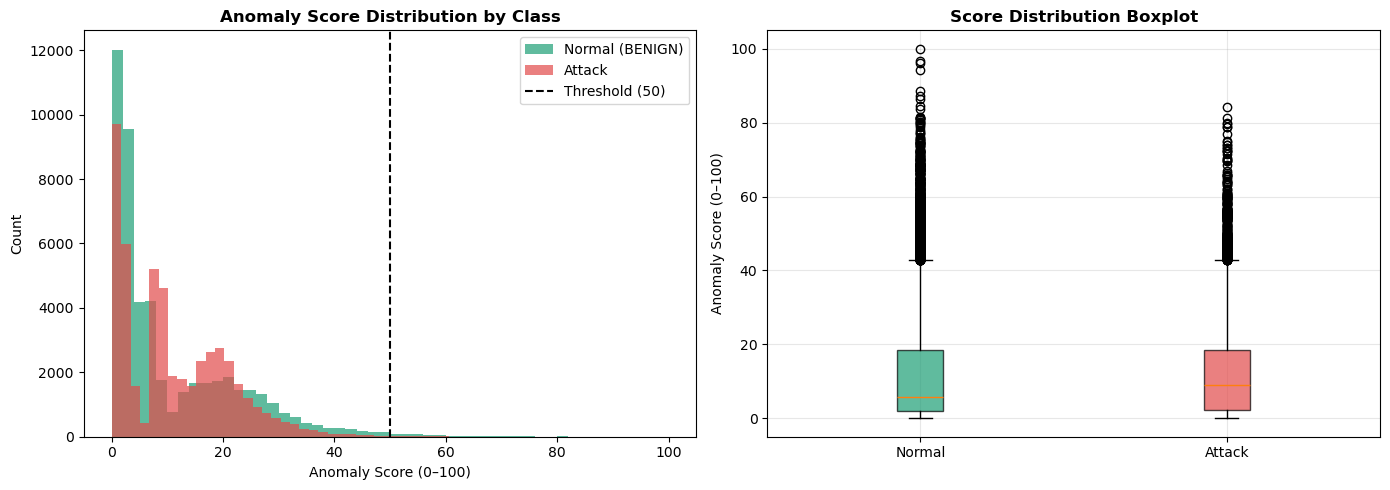

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution by class
ax1.hist(
    df_balanced[df_balanced["label"]==0]["anomaly_score"],
    bins=50, alpha=0.7, color="#1D9E75", label="Normal (BENIGN)"
)
ax1.hist(
    df_balanced[df_balanced["label"]==1]["anomaly_score"],
    bins=50, alpha=0.7, color="#E24B4A", label="Attack"
)
ax1.axvline(x=50, color="black", linestyle="--", lw=1.5, label="Threshold (50)")
ax1.set_title("Anomaly Score Distribution by Class", fontsize=12, fontweight="bold")
ax1.set_xlabel("Anomaly Score (0–100)")
ax1.set_ylabel("Count")
ax1.legend()

# Attack type score comparison
attack_scores = df_balanced[df_balanced["label"]==1]["anomaly_score"]
normal_scores = df_balanced[df_balanced["label"]==0]["anomaly_score"]

bp_data = [normal_scores.values, attack_scores.values]
bp = ax2.boxplot(bp_data, labels=["Normal", "Attack"], patch_artist=True)
bp["boxes"][0].set_facecolor("#1D9E75")
bp["boxes"][1].set_facecolor("#E24B4A")
for patch in bp["boxes"]:
    patch.set_alpha(0.7)

ax2.set_title("Score Distribution Boxplot", fontsize=12, fontweight="bold")
ax2.set_ylabel("Anomaly Score (0–100)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [20]:
joblib.dump(model, "../models/isolation_forest.pkl")
print("✅ Model saved → ../models/isolation_forest.pkl")

test_normal = np.array([[
    10,     # requests_per_ip
    1500,   # payload_size
    50000,  # response_time (microseconds in this dataset)
    64,     # error_rate (avg packet size)
    100,    # suspicious_endpoint
    200,    # suspicious_agent
]])

test_attack = np.array([[
    99999,  # requests_per_ip — very high (DDoS)
    0,      # payload_size — zero bytes
    10,     # response_time — near zero
    0,      # error_rate
    0,      # suspicious_endpoint
    0,      # suspicious_agent
]])

scaler = joblib.load("../models/scaler.pkl")

n_pred  = model.predict(scaler.transform(test_normal))
a_pred  = model.predict(scaler.transform(test_attack))
n_score = model.decision_function(scaler.transform(test_normal))
a_score = model.decision_function(scaler.transform(test_attack))

print("\n=== Model Test Results ===")
print(f"Normal entry → {'NORMAL' if n_pred[0]==1 else '⚠️ ANOMALY'} (raw score: {n_score[0]:.3f})")
print(f"Attack entry → {'NORMAL' if a_pred[0]==1 else '🔴 ANOMALY'} (raw score: {a_score[0]:.3f})")

✅ Model saved → ../models/isolation_forest.pkl

=== Model Test Results ===
Normal entry → NORMAL (raw score: 0.070)
Attack entry → NORMAL (raw score: 0.074)


In [21]:
print("=" * 50)
print("  SentinelLog — Training Complete")
print("=" * 50)
print(f"\n  Dataset     : CICIDS2017 Cleaned")
print(f"  Samples     : {len(df_balanced):,}")
print(f"  Features    : {len(FEATURE_COLS)}")
print(f"  Estimators  : 200 trees")
print(f"  Flagged     : {df_balanced['is_anomaly'].sum():,} anomalies")
print(f"\n  Saved files :")
print(f"  ../models/isolation_forest.pkl")
print(f"  ../models/scaler.pkl")
print(f"\n  Output charts :")
print(f"  outputs/feature_distributions.png")
print(f"  outputs/normal_vs_attack.png")
print(f"  outputs/confusion_matrix.png")
print(f"  outputs/roc_curve.png")
print(f"  outputs/score_distribution.png")
print(f"\n  Next → start backend:")
print(f"  cd ../backend && uvicorn main:app --reload")
print("=" * 50)

  SentinelLog — Training Complete

  Dataset     : CICIDS2017 Cleaned
  Samples     : 100,000
  Features    : 6
  Estimators  : 200 trees
  Flagged     : 15,000 anomalies

  Saved files :
  ../models/isolation_forest.pkl
  ../models/scaler.pkl

  Output charts :
  outputs/feature_distributions.png
  outputs/normal_vs_attack.png
  outputs/confusion_matrix.png
  outputs/roc_curve.png
  outputs/score_distribution.png

  Next → start backend:
  cd ../backend && uvicorn main:app --reload
